In [95]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
from scipy.stats import t, sem
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [ ]:

def asset_return(ticker_list): # function to get the asset return dataframe
    ticker_return = []
    for ticker in ticker_list.keys():
        ticker = yf.Ticker(ticker)
        ticker_df = ticker.history(period='max') # up to 100 years of historical data
        ticker_df['Return'] = ticker_df['Close'].pct_change().dropna(how='any')
        ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]')) # make index yyyy-mm-dd
        ticker_return.append(ticker_df['Return'])
    
    ticker_return = pd.concat(ticker_return, axis=1).ffill().dropna(how='any')
    ticker_return.columns = ticker_list.values()
    
    ticker_return[ticker_return<-1] = -0.50 # something is wrong with crude oil data, cannot have < -100% return
    
    return ticker_return


def asset_return_normalized(ticker_df):
    return ticker_df.apply(lambda x: pd.Series((x-x.mean())/x.std()))


def asset_return_chi_square(ticker_df):
    #return ((ticker_df*ticker_df).sum(axis=1)/len(ticker_df.columns)).to_frame().rename(columns={0:'chi'})
    # calculate chi-square with 5 standardized asset returns
    ticker_df["chi"]=(ticker_df*ticker_df).sum(axis=1)/len(ticker_df.columns)
    return ticker_df


def asset_return_histogram(ticker_df):
    mu = 0
    sigma = 1
    n = 1000
    
    # histogram with standard normal distribution for 5 assets
    fig, axes = plt.subplots(ticker_df.shape[1], 1, figsize=(15, 15))
    plt.subplots_adjust(hspace = 0.5)
    for ax, ticker_df_column in zip(axes, ticker_df.columns[:-1]):
        ax_hist = sns.histplot(data=ticker_df[ticker_df_column], bins=250, ax=ax)
        ax = ax_hist.twinx()
        x = np.linspace(ticker_df[ticker_df_column].min(),ticker_df[ticker_df_column].max(),1000)
        y = stats.norm.pdf(x, mu, sigma)                
        ax_norm = sns.lineplot(x=x, y=y, ax=ax, color='red')
        ax.set_title('return histogram of '+ticker_df_column, fontsize=8)
        ax.set(ylabel = '')
        ax.set(xlabel = '')
    
    # histogram with chi-square distribution for chi-square data
    ax_hist = sns.histplot(data=ticker_df[ticker_df.columns[-1]], bins=1000, ax=axes[-1])
    axes[-1] = ax_hist.twinx()
    x = np.linspace(0,10,1000)
    y = stats.chi2.pdf(x, ticker_df.shape[1]-1)              
    ax_chi = sns.lineplot(x=x, y=y, ax=axes[-1], color='red')
      
    axes[-1].set_title('Chi histogram of '+ticker_df.columns[-1], fontsize=8)
    axes[-1].set(ylabel = '')
    axes[-1].set(xlabel = '')
    axes[-1].set(xlim=(0,10))
    
    return(fig)

In [ ]:


# list of assets
ticker_list = {'^GSPC':'SP500', 
               '^TNX':'10Y Bond',
               'CL=F':'Crude Oil', 
               'GC=F': 'Gold', 
               'BTC-USD': 'Bitcoin'}

# dataframe of asset return
asset_return_df = asset_return(ticker_list)

# dataframe of normalized asset return
asset_return_norm_df = asset_return_normalized(asset_return_df)

# dataframe of Chi-square
asset_return_chi_square_df = asset_return_chi_square(asset_return_norm_df.copy())

In [98]:
asset_return_df
#asset_return_norm_df
#asset_return_chi_square_df

,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
2014-09-18,0.004891,0.011154,-0.014298,-0.007048,-0.071926
2014-09-19,-0.000477,-0.015976,-0.007091,-0.008485,-0.069843
2014-09-20,-0.000477,-0.015976,-0.007091,-0.008485,0.035735
2014-09-21,-0.000477,-0.015976,-0.007091,-0.008485,-0.024659
2014-09-22,-0.008013,-0.008117,-0.009631,0.001234,0.008352
...,...,...,...,...,...
2026-03-24,-0.003743,0.013383,0.047884,-0.001090,-0.005598
2026-03-25,0.005419,-0.014572,-0.021982,0.034210,0.011232
2026-03-26,-0.017406,0.020333,0.046058,-0.038309,-0.035314
2026-03-27,-0.016722,0.005435,0.054615,0.034007,-0.035662


In [99]:
#asset_ret_hist = asset_return_histogram(asset_return_chi_square_df)

In [ ]:

def asset_return_rand_replace(ticker_df, ticker='SP500', replace=True): 


    n = 100 # sample size
    ns = 10 # number of samples
    
    sample_list = []
    for i in range(ns):
        # sample 100 observations randomly by using the pd.sample() method
        sample = ticker_df.sample(n).sort_index()[ticker].to_frame().rename(columns={ticker:'sample_'+str(i+1)}).reset_index(drop=True)
        sample_list.append(sample)
        if (replace==True):
            ticker_df= ticker_df[~ticker_df.index.isin(sample.index)]
    sample_list = pd.concat(sample_list, axis=1)
    
    return sample_list

def asset_return_stratified(ticker_df, ticker='SP500'):

    n = 100 # sample size
    ns = 10 # number of samples
    
    sample_list = []
    for i in ticker_df.index.year.unique()[0:ns]:
        sample_period = pd.date_range(datetime(i,10,1), periods=n, freq='D')
        sample = ticker_df.loc[sample_period,ticker].to_frame().rename(columns={ticker:'sample_'+str(i+1)}).reset_index(drop=True)
        sample_list.append(sample)
    sample_list = pd.concat(sample_list, axis=1)
    
    return sample_list    


def sample_des_stats(sample): # function to get the asset return descriptive statistics
    sample_des = sample.describe()
    sample_skewness = sample.skew()
    sample_kurtosis = stats.kurtosis(sample, fisher=True)     
    
    # standard error of mean (SEM)
    sample_std_error = sem(sample)

    # confidence interval, upper and lower
    sample_ci = t.interval(confidence=.95, df=len(sample)-1,loc=np.mean(sample), scale=sem(sample))   
    
    sample_misc = pd.DataFrame([sample_skewness, sample_kurtosis, sample_std_error, sample_ci[0], sample_ci[1]], 
                               index=['skewness','kurtosis','std_err_mean (sem)','ci_lower', 'ci_upper'],
                               columns=[sample.name])
    sample_des_stats = pd.concat([sample_des.to_frame(), sample_misc], axis=0)[sample.name]
    
    return(sample_des_stats)

def sample_plots(sample_list, asset_return_df, ticker='SP500'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plt.subplots_adjust(hspace = 0.25, wspace = 0.25)
    
    # kde (probability density) plots for population and samples
    ## kde plots of the samples
    ax_kde_s = sns.kdeplot(data=sample_list,lw=0.5,linestyle='--', ax=axes[0])
    axes[0] = ax_kde_s.twinx()  
    ## kde plot of the population
    ax_kde_p = sns.kdeplot(data=asset_return_df[ticker],lw=1,color='red',label='population',ax=axes[0])
    plt.legend()
      
    axes[0].set_title('kde plots of population and samles '+ticker, fontsize=8)
    axes[0].set(ylabel = '')
    axes[0].set(xlabel = '')
    
    # confidence interval plots
    # collect the upper and lower CI bounds, and the sample means for each experiment
    uppers = []
    lowers = []
    sample_means = []
    pop_mean = asset_return_df[ticker].describe()['mean'] # population mean
    #pop_std = asset_return_df[ticker].describe()['std'] # population standard deviation
    
    for column in sample_list.columns:
        sample_means.append(statistics.mean(sample_list[column]))
        ci = t.interval(confidence=.95, df=len(sample_list[column])-1, 
                        loc=np.mean(sample_list[column]), scale=sem(sample_list[column]))
        uppers.append(ci[1])
        lowers.append(ci[0])
    

    x = list(range(0,len(sample_list.columns)))
    too_high = [x[s] for s, val in enumerate(lowers) if val > pop_mean]
    too_low = [x[s] for s, val in enumerate(uppers) if val < pop_mean]
    no_mean = too_high + too_low
    highlight = ['blue']*len(sample_list.columns)
    for s, val in enumerate(no_mean):
        highlight[val] = 'red'
    
    # plot the data and format the plots
    ax_ci = sns.pointplot(x=sample_list.columns, y=sample_means, join=False, ax=axes[1])
    axes[1].vlines(x=sample_list.columns, ymin=lowers, ymax=uppers, color = highlight)
    axes[1].axhline(y=pop_mean, linestyle = "--")
    axes[1].set_xticklabels(axes[1].get_xmajorticklabels(),fontsize=7)
    axes[1].set_title("confidence interval - " + ticker)
    axes[1].set(ylabel=None)
    axes[1].spines[['top', 'right']].set_visible(False)
    
    return(fig)    

In [101]:
sample_list_without_replace = asset_return_rand_replace(asset_return_df, ticker='SP500', replace=True)
sample_list_des_stats = sample_list_without_replace.apply(sample_des_stats)
sample_list_des_stats

,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.000494,0.000988,0.001019,-0.001621,-0.001567,0.001498,0.003050,0.000509,0.000202,0.000938
std,0.013043,0.008296,0.010257,0.010015,0.013896,0.009868,0.016826,0.008075,0.009971,0.011153
min,-0.059750,-0.024522,-0.025946,-0.043360,-0.095113,-0.018278,-0.044163,-0.020588,-0.033687,-0.029294
25%,-0.005322,-0.002149,-0.002873,-0.004952,-0.005672,-0.002743,-0.001865,-0.003099,-0.003010,-0.005080
50%,0.000145,0.001194,0.001604,0.000111,-0.000189,0.000912,0.001693,-0.000262,0.000446,0.001292
75%,0.005519,0.004181,0.004643,0.003770,0.005386,0.004795,0.007788,0.005405,0.006625,0.006091
max,0.030584,0.026794,0.046039,0.023725,0.026794,0.049396,0.095154,0.026212,0.018341,0.055434
skewness,-1.251621,-0.141931,0.517083,-1.380061,-3.318110,1.563896,2.704795,0.066395,-1.078474,0.924436
kurtosis,4.539777,1.741232,3.554515,3.488636,19.370636,6.194702,15.955600,0.621356,1.989067,5.312111


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:111: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax_ci = sns.pointplot(x=sample_list.columns, y=sample_means, join=False, ax=axes[1])
/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(),fontsize=7)


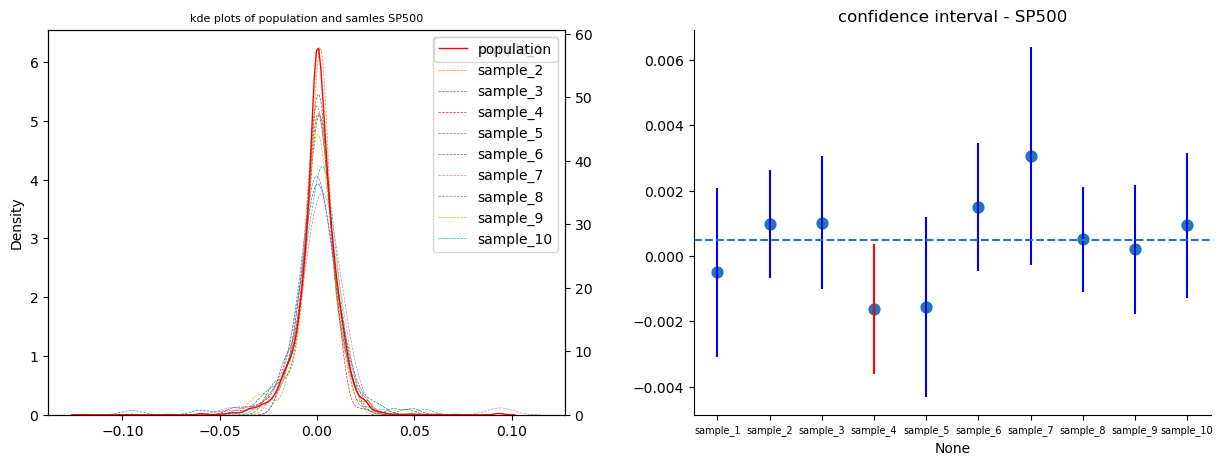

In [102]:
sample_des_plots = sample_plots(sample_list_without_replace, asset_return_df, ticker='SP500')

In [103]:
sample_list_with_replace = asset_return_rand_replace(asset_return_df, ticker='SP500', replace=False)
sample_list_des_stats = sample_list_with_replace.apply(sample_des_stats)
sample_list_des_stats

,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.000763,0.000004,-0.000777,0.001234,-0.000948,0.000291,0.000616,-0.000696,-0.000593,0.000083
std,0.008664,0.010521,0.012852,0.011230,0.015243,0.009604,0.008985,0.008630,0.012385,0.008905
min,-0.027740,-0.043360,-0.075970,-0.033687,-0.095113,-0.029518,-0.022725,-0.033688,-0.036285,-0.034608
25%,-0.002497,-0.003863,-0.004151,-0.002004,-0.004453,-0.003243,-0.003981,-0.003098,-0.006085,-0.003101
50%,0.001115,0.000321,0.000852,0.000850,0.000678,0.000383,0.000740,0.000610,-0.000511,0.000758
75%,0.005271,0.004998,0.006123,0.005307,0.005600,0.004803,0.005132,0.004472,0.005185,0.005309
max,0.019696,0.024348,0.024760,0.062414,0.030563,0.034336,0.022841,0.015532,0.062414,0.018313
skewness,-0.486075,-0.801805,-2.292299,1.186633,-3.054042,-0.368587,-0.012060,-1.173957,1.055032,-0.955286
kurtosis,1.074555,2.586682,10.550907,8.448361,15.513602,2.488902,0.091464,2.551342,6.322296,2.261293


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:111: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax_ci = sns.pointplot(x=sample_list.columns, y=sample_means, join=False, ax=axes[1])
/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(),fontsize=7)


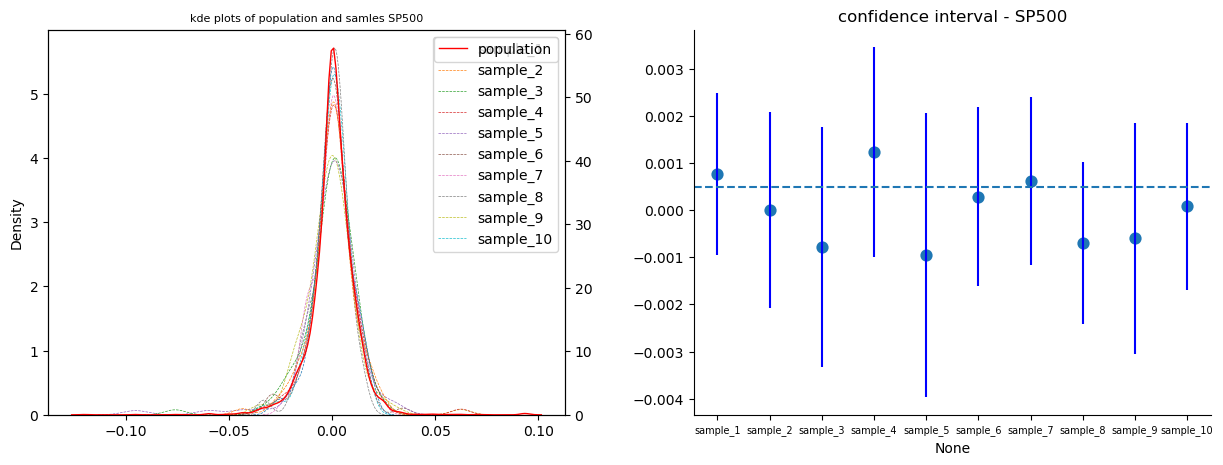

In [104]:
sample_des_plots = sample_plots(sample_list_with_replace, asset_return_df, ticker='SP500')

In [105]:
sample_list_stratified = asset_return_stratified(asset_return_df, ticker='SP500')
sample_list_des_stats = sample_list_stratified.apply(sample_des_stats)
sample_list_des_stats

,sample_2015,sample_2016,sample_2017,sample_2018,sample_2019,sample_2020,sample_2021,sample_2022,sample_2023,sample_2024
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.000952,-0.000248,0.000571,0.001415,-0.002649,0.001980,0.001680,0.000878,0.001310,0.001611
std,0.008911,0.010144,0.004831,0.003827,0.015530,0.005946,0.009309,0.008764,0.015484,0.007381
min,-0.020661,-0.023700,-0.012446,-0.005526,-0.032864,-0.017903,-0.035288,-0.022725,-0.028004,-0.014684
25%,-0.002542,-0.006866,-0.002506,-0.001054,-0.015490,-0.001236,-0.003511,-0.003042,-0.008026,-0.002826
50%,0.000716,-0.000348,0.000059,0.000964,-0.001330,0.002185,0.002094,0.001885,-0.001195,0.001514
75%,0.005237,0.005511,0.003547,0.003747,0.006447,0.005767,0.007741,0.006652,0.010067,0.005874
max,0.024015,0.020526,0.022224,0.009849,0.049594,0.014217,0.022047,0.020707,0.055434,0.019075
skewness,-0.141497,0.017987,0.974385,0.358004,0.436669,-0.498035,-0.563653,-0.523047,0.447168,-0.030369
kurtosis,0.143176,-0.477609,3.277199,-0.570763,0.643899,0.848269,1.444263,0.476481,0.399239,-0.000168


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:111: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax_ci = sns.pointplot(x=sample_list.columns, y=sample_means, join=False, ax=axes[1])
/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/1281661906.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(),fontsize=7)


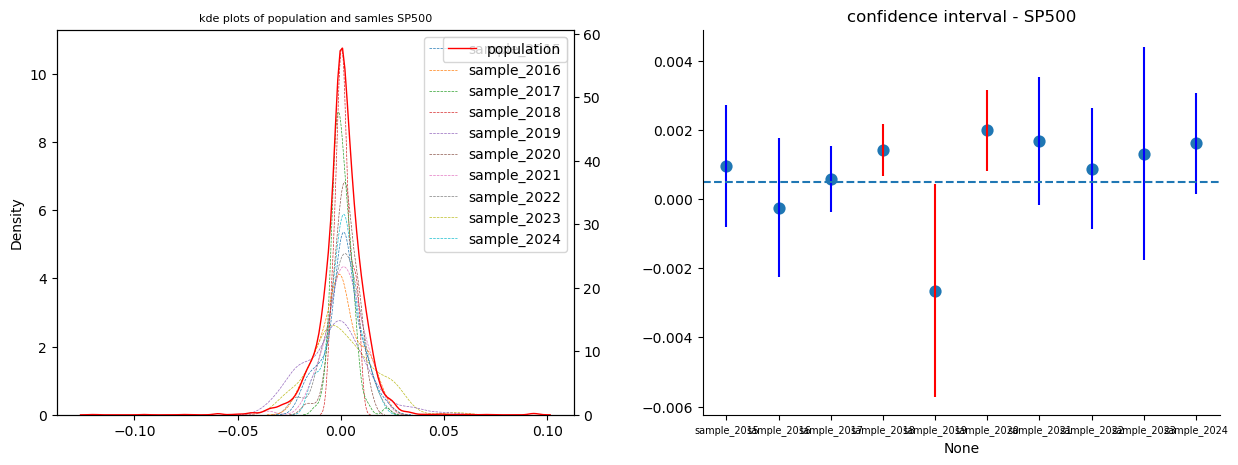

In [106]:
sample_des_plots = sample_plots(sample_list_stratified, asset_return_df, ticker='SP500')

In [107]:
# ── 1. Fetch asset returns ──────────────────────────────────
def fetch_returns(ticker_dict):
    """
    Download historical daily returns for each ticker.
    Returns a DataFrame aligned on calendar dates.
    """
    series_list = []
    for symbol, label in ticker_dict.items():
        raw = yf.Ticker(symbol).history(period='max')
        pct = raw['Close'].pct_change().dropna()
        pct.index = pd.Index(pct.index.values.astype('M8[D]'))
        pct.name = label
        series_list.append(pct)
    df = pd.concat(series_list, axis=1).ffill().dropna(how='any')
    df[df < -1] = -0.50  # cap bad crude-oil returns
    return df


# ── 2. Normalise returns (z-score) ──────────────────────────
def normalize_returns(df):
    """Z-score each column independently."""
    return df.apply(lambda col: (col - col.mean()) / col.std())


# ── 3. Append pseudo chi-square column ──────────────────────
def add_chi_square_column(df):
    """Mean of squared standardised returns across assets per day."""
    out = df.copy()
    out['chi'] = (df ** 2).sum(axis=1) / df.shape[1]
    return out


# ── 4. Simple random sampling ────────────────────────────────
def simple_random_sample(returns_df, asset='SP500', with_replacement=False):
    """
    Draw 10 simple random samples of size 100.
    with_replacement=False -> without replacement (default)
    with_replacement=True  -> with replacement
    """
    N_SAMPLES   = 10
    SAMPLE_SIZE = 100
    pool = returns_df.copy()
    collected = []
    for i in range(N_SAMPLES):
        draw = pool.sample(n=SAMPLE_SIZE)
        draw = draw.sort_index()[asset].rename(f'sample_{i + 1}').reset_index(drop=True)
        collected.append(draw)
        if not with_replacement:
            pool = pool[~pool.index.isin(draw.index)]
    return pd.concat(collected, axis=1)


# ── 5. Stratified sampling ───────────────────────────────────
def stratified_sample(returns_df, asset='SP500'):
    """
    One sample per calendar year (first 10 years in the data),
    each starting on Oct 1 and covering 100 consecutive calendar days.
    """
    N_SAMPLES   = 10
    SAMPLE_SIZE = 100
    years = returns_df.index.year.unique()[:N_SAMPLES]
    collected = []
    for yr in years:
        dates = pd.date_range(datetime(yr, 10, 1), periods=SAMPLE_SIZE, freq='D')
        draw = returns_df.loc[dates, asset].rename(f'sample_{yr + 1}').reset_index(drop=True)
        collected.append(draw)
    return pd.concat(collected, axis=1)


# ── 6. Extended descriptive statistics ──────────────────────
def compute_sample_stats(series):
    """
    Compute count/mean/std/min/25%/50%/75%/max,
    skewness, excess kurtosis, SEM, and 95% CI bounds.
    """
    base = series.describe()
    ci_lo, ci_hi = t.interval(
        confidence=0.95,
        df=len(series) - 1,
        loc=np.mean(series),
        scale=sem(series),
    )
    extra = pd.Series(
        {
            'skewness':           series.skew(),
            'kurtosis':           stats.kurtosis(series, fisher=True),
            'std_err_mean (sem)': sem(series),
            'ci_lower':           ci_lo,
            'ci_upper':           ci_hi,
        },
        name=series.name,
    )
    return pd.concat([base.to_frame(), extra.to_frame()], axis=0)[series.name]


# ── 7. KDE + Confidence-Interval plot ───────────────────────
def plot_kde_and_ci(samples_df, full_returns_df, asset='SP500'):
    """
    Left panel : KDE of each sample (dashed) + population KDE (red)
    Right panel: 95% CI for each sample mean;
                 CIs that miss the population mean are shown in red.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plt.subplots_adjust(hspace=0.25, wspace=0.25)

    # -- Left: KDE --
    ax_s = sns.kdeplot(data=samples_df, lw=0.5, linestyle='--', ax=axes[0])
    axes[0] = ax_s.twinx()
    sns.kdeplot(
        data=full_returns_df[asset], lw=1, color='red',
        label='population', ax=axes[0],
    )
    plt.legend()
    axes[0].set_title(f'KDE – population vs samples ({asset})', fontsize=8)
    axes[0].set(ylabel='', xlabel='')

    # -- Right: Confidence Intervals --
    pop_mean = full_returns_df[asset].mean()
    means, lowers, uppers = [], [], []
    for col in samples_df.columns:
        s = samples_df[col]
        means.append(s.mean())
        lo, hi = t.interval(0.95, df=len(s) - 1, loc=np.mean(s), scale=sem(s))
        lowers.append(lo)
        uppers.append(hi)

    x_pos = list(range(len(samples_df.columns)))
    missed = set(
        [x_pos[i] for i, lo in enumerate(lowers) if lo > pop_mean] +
        [x_pos[i] for i, hi in enumerate(uppers) if hi < pop_mean]
    )
    colours = ['red' if i in missed else 'blue' for i in x_pos]

    sns.pointplot(x=samples_df.columns, y=means, linestyles='none', ax=axes[1])
    axes[1].vlines(x=samples_df.columns, ymin=lowers, ymax=uppers, color=colours)
    axes[1].axhline(y=pop_mean, linestyle='--')
    axes[1].set_xticklabels(axes[1].get_xmajorticklabels(), fontsize=7)
    axes[1].set_title(f'Confidence Intervals – {asset}')
    axes[1].set(ylabel=None)
    axes[1].spines[['top', 'right']].set_visible(False)

    return fig


In [108]:
# ── Function calls: retrieve and prepare data ─────────────
TICKERS = {
    '^GSPC':   'SP500',
    '^TNX':    '10Y Bond',
    'CL=F':    'Crude Oil',
    'GC=F':    'Gold',
    'BTC-USD': 'Bitcoin',
}

student_returns_df = fetch_returns(TICKERS)       # raw returns
student_norm_df    = normalize_returns(student_returns_df)  # z-scored
student_chi_sq_df  = add_chi_square_column(student_norm_df.copy())  # + chi col

student_returns_df  # display


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
2014-09-18,0.004891,0.011154,-0.014298,-0.007048,-0.071926
2014-09-19,-0.000477,-0.015976,-0.007091,-0.008485,-0.069843
2014-09-20,-0.000477,-0.015976,-0.007091,-0.008485,0.035735
2014-09-21,-0.000477,-0.015976,-0.007091,-0.008485,-0.024659
2014-09-22,-0.008013,-0.008117,-0.009631,0.001234,0.008352
...,...,...,...,...,...
2026-03-24,-0.003743,0.013383,0.047884,-0.001090,-0.005598
2026-03-25,0.005419,-0.014572,-0.021982,0.034210,0.011232
2026-03-26,-0.017406,0.020333,0.046058,-0.038309,-0.035314
2026-03-27,-0.016722,0.005435,0.054615,0.034007,-0.035662


,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.000147,0.000726,-0.001623,0.001036,0.002511,0.000226,-0.000481,0.000612,0.000506,0.001312
std,0.009224,0.009052,0.012502,0.010023,0.010624,0.008978,0.011551,0.009376,0.008894,0.009584
min,-0.032365,-0.023700,-0.059750,-0.021209,-0.032365,-0.029110,-0.051831,-0.035126,-0.023721,-0.021599
25%,-0.003078,-0.003322,-0.005266,-0.004125,-0.001517,-0.004088,-0.004110,-0.004308,-0.005011,-0.003277
50%,0.000103,0.001030,-0.000156,0.000324,0.001643,0.000055,0.000803,0.000788,0.001522,0.000911
75%,0.003957,0.006977,0.004936,0.006390,0.006658,0.004273,0.006327,0.006437,0.007284,0.005387
max,0.026480,0.022829,0.024348,0.032559,0.062414,0.024477,0.024742,0.022930,0.018962,0.031501
skewness,-0.529158,-0.425072,-1.594195,0.214425,1.411859,-0.129072,-1.623164,-0.704291,-0.569923,0.156024
kurtosis,2.097835,0.390549,4.946971,0.631830,9.644695,1.131550,4.445311,1.729293,0.176113,0.682778


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/2834686160.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(), fontsize=7)


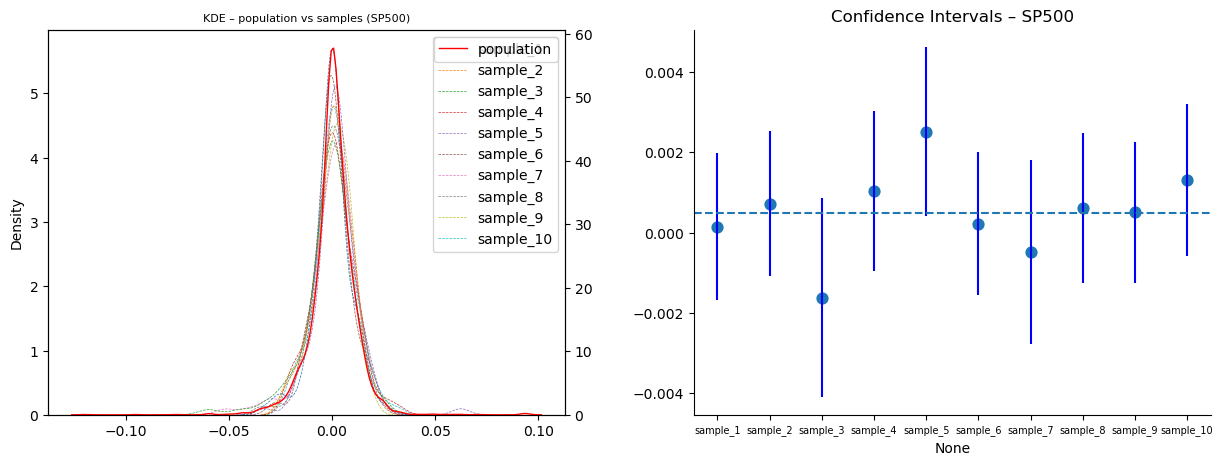

In [109]:
# ── Sampling WITHOUT replacement ──────────────────────────
samples_no_replace = simple_random_sample(
    student_returns_df, asset='SP500', with_replacement=False
)
stats_no_replace = samples_no_replace.apply(compute_sample_stats)
display(stats_no_replace)
fig1 = plot_kde_and_ci(samples_no_replace, student_returns_df, asset='SP500')
plt.show()


,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.001826,0.001596,-0.000715,0.003328,0.000857,-0.000980,-0.000183,0.001713,0.000157,0.002321
std,0.015439,0.014143,0.011669,0.012623,0.012282,0.010849,0.012577,0.010702,0.014654,0.016146
min,-0.095113,-0.035920,-0.051831,-0.029576,-0.025946,-0.051831,-0.040395,-0.033688,-0.059750,-0.058944
25%,-0.005329,-0.002105,-0.004678,-0.000966,-0.004749,-0.005589,-0.007756,-0.002593,-0.004568,-0.003737
50%,-0.000058,0.001038,0.000072,0.001916,0.000348,-0.000719,0.001853,0.001405,0.002070,0.000562
75%,0.004398,0.005161,0.006807,0.006320,0.005243,0.004914,0.006556,0.006818,0.006447,0.007077
max,0.042203,0.095154,0.022373,0.092871,0.092871,0.026212,0.034056,0.026212,0.070331,0.092871
skewness,-2.708985,2.634243,-1.261373,3.489472,4.086391,-1.117265,-0.417270,-0.427967,0.144053,1.717905
kurtosis,14.083782,18.455571,3.308954,24.435530,29.855951,4.200104,0.709150,1.261182,6.562178,11.513180


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/2834686160.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(), fontsize=7)


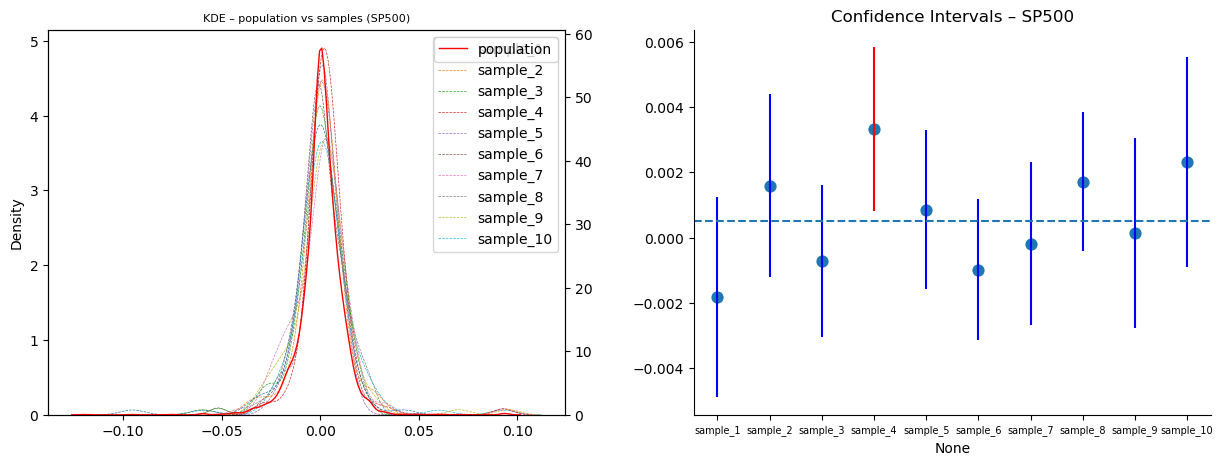

In [110]:
# ── Sampling WITH replacement ─────────────────────────────
samples_with_replace = simple_random_sample(
    student_returns_df, asset='SP500', with_replacement=True
)
stats_with_replace = samples_with_replace.apply(compute_sample_stats)
display(stats_with_replace)
fig2 = plot_kde_and_ci(samples_with_replace, student_returns_df, asset='SP500')
plt.show()


,sample_2015,sample_2016,sample_2017,sample_2018,sample_2019,sample_2020,sample_2021,sample_2022,sample_2023,sample_2024
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.000952,-0.000248,0.000571,0.001415,-0.002649,0.001980,0.001680,0.000878,0.001310,0.001611
std,0.008911,0.010144,0.004831,0.003827,0.015530,0.005946,0.009309,0.008764,0.015484,0.007381
min,-0.020661,-0.023700,-0.012446,-0.005526,-0.032864,-0.017903,-0.035288,-0.022725,-0.028004,-0.014684
25%,-0.002542,-0.006866,-0.002506,-0.001054,-0.015490,-0.001236,-0.003511,-0.003042,-0.008026,-0.002826
50%,0.000716,-0.000348,0.000059,0.000964,-0.001330,0.002185,0.002094,0.001885,-0.001195,0.001514
75%,0.005237,0.005511,0.003547,0.003747,0.006447,0.005767,0.007741,0.006652,0.010067,0.005874
max,0.024015,0.020526,0.022224,0.009849,0.049594,0.014217,0.022047,0.020707,0.055434,0.019075
skewness,-0.141497,0.017987,0.974385,0.358004,0.436669,-0.498035,-0.563653,-0.523047,0.447168,-0.030369
kurtosis,0.143176,-0.477609,3.277199,-0.570763,0.643899,0.848269,1.444263,0.476481,0.399239,-0.000168


/var/folders/38/314bl63504d18kj1ml_g2xmc0000gn/T/ipykernel_49592/2834686160.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xmajorticklabels(), fontsize=7)


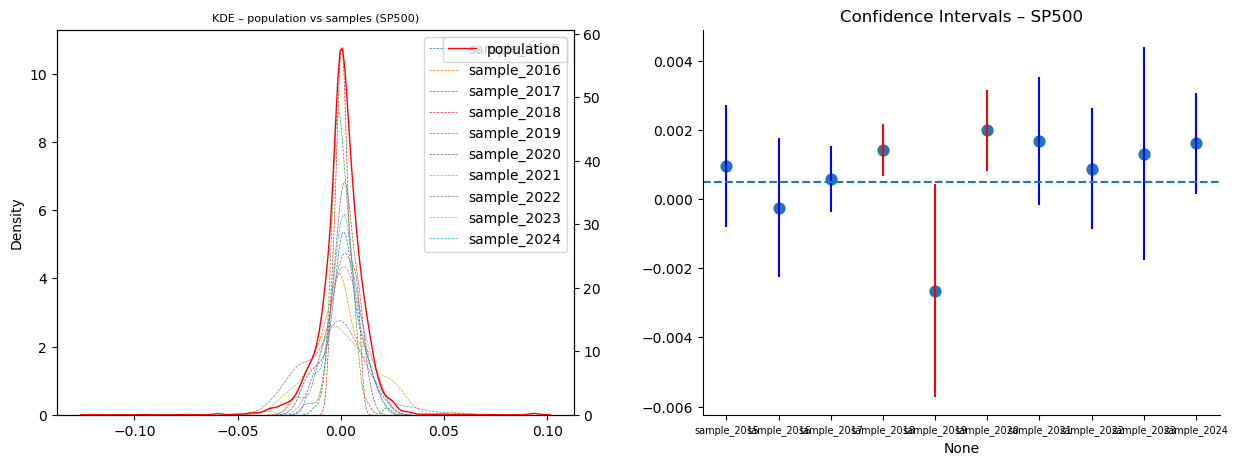

In [111]:
# ── Stratified sampling ────────────────────────────────────
samples_stratified = stratified_sample(student_returns_df, asset='SP500')
stats_stratified   = samples_stratified.apply(compute_sample_stats)
display(stats_stratified)
fig3 = plot_kde_and_ci(samples_stratified, student_returns_df, asset='SP500')
plt.show()
